# Predicting Movie Genre Performance: EDA and Baseline Modeling

**Scope:** Analysis uses the Kaggle *Movies Dataset* (TMDB metadata), covering films released **on or before July 2017**. Results reflect **all languages** (no English-only filter). The goal is to explore whether genre performance can be predicted from metadata (budget, release info, cast/crew, keywords) and to build baseline models to quantify predictability.


In [1]:
import pandas as pd, numpy as np, json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

pd.set_option("display.max_columns", 200)
sns.set_context("talk")
rand = 42


In [4]:
# Minimal columns for analysis; CSVs are under ./data
movies_meta = pd.read_csv("data/movies_metadata.csv", low_memory=False)
movies_meta = movies_meta[[
    "id", "imdb_id", "title", "release_date",
    "budget", "revenue", "runtime", "original_language", "genres",
    "vote_average", "vote_count"
]]

# Use movies_meta (not "movies")
movies_meta["release_date"] = pd.to_datetime(movies_meta["release_date"], errors="coerce")
movies_meta["release_year"]  = movies_meta["release_date"].dt.year
movies_meta["release_month"] = movies_meta["release_date"].dt.month

for c in ["budget", "revenue", "runtime", "vote_average", "vote_count"]:
    movies_meta[c] = pd.to_numeric(movies_meta[c], errors="coerce")

print("movies_meta:", movies_meta.shape)
movies_meta.head(3)


movies_meta: (45466, 13)


,id,imdb_id,title,release_date,budget,revenue,runtime,original_language,genres,vote_average,vote_count,release_year,release_month
0,862,tt0114709,Toy Story,1995-10-30,30000000.0,373554033.0,81.0,en,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",7.7,5415.0,1995.0,10.0
1,8844,tt0113497,Jumanji,1995-12-15,65000000.0,262797249.0,104.0,en,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",6.9,2413.0,1995.0,12.0
2,15602,tt0113228,Grumpier Old Men,1995-12-22,0.0,0.0,101.0,en,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",6.5,92.0,1995.0,12.0


In [5]:
def parse_list(s):
    try:
        return json.loads(str(s).replace("'", '"'))
    except Exception:
        return []

def primary_genre(s):
    lst = parse_list(s)
    return lst[0]["name"] if isinstance(lst, list) and len(lst) else None

movies_meta["genres_primary"] = movies_meta["genres"].apply(primary_genre)

# trying to enrich the data
credits  = pd.read_csv("data/credits.csv",  engine="python", on_bad_lines="skip", dtype={"id":str})
keywords = pd.read_csv("data/keywords.csv", engine="python", on_bad_lines="skip", dtype={"id":str})
movies_meta["id"] = movies_meta["id"].astype(str)

def get_director(crew):
    lst = parse_list(crew)
    if isinstance(lst, list):
        for m in lst:
            if m.get("job") == "Director":
                return m.get("name")
    return None

def get_top_actor(cast):
    lst = parse_list(cast)
    return lst[0]["name"] if isinstance(lst, list) and len(lst) else None

credits["director"]  = credits["crew"].apply(get_director)
credits["top_actor"] = credits["cast"].apply(get_top_actor)

keywords["kw_list"]      = keywords["keywords"].apply(parse_list)
keywords["num_keywords"] = keywords["kw_list"].apply(lambda x: len(x) if isinstance(x, list) else 0)

movies_full = (
    movies_meta
    .merge(credits[["id","director","top_actor"]], on="id", how="left")
    .merge(keywords[["id","num_keywords"]],       on="id", how="left")
    .copy()
)

# helper transforms
movies_full["budget_log"]  = np.log1p(movies_full["budget"])
movies_full["revenue_log"] = np.log1p(movies_full["revenue"])
movies_full.head(3)


,id,imdb_id,title,release_date,budget,revenue,runtime,original_language,genres,vote_average,vote_count,release_year,release_month,genres_primary,director,top_actor,num_keywords,budget_log,revenue_log
0,862,tt0114709,Toy Story,1995-10-30,30000000.0,373554033.0,81.0,en,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",7.7,5415.0,1995.0,10.0,Animation,None,None,9.0,17.216708,19.738573
1,8844,tt0113497,Jumanji,1995-12-15,65000000.0,262797249.0,104.0,en,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",6.9,2413.0,1995.0,12.0,Adventure,None,None,0.0,17.989898,19.386893
2,15602,tt0113228,Grumpier Old Men,1995-12-22,0.0,0.0,101.0,en,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",6.5,92.0,1995.0,12.0,Romance,None,Walter Matthau,4.0,0.000000,0.000000


## Exploratory Data Analysis (EDA)

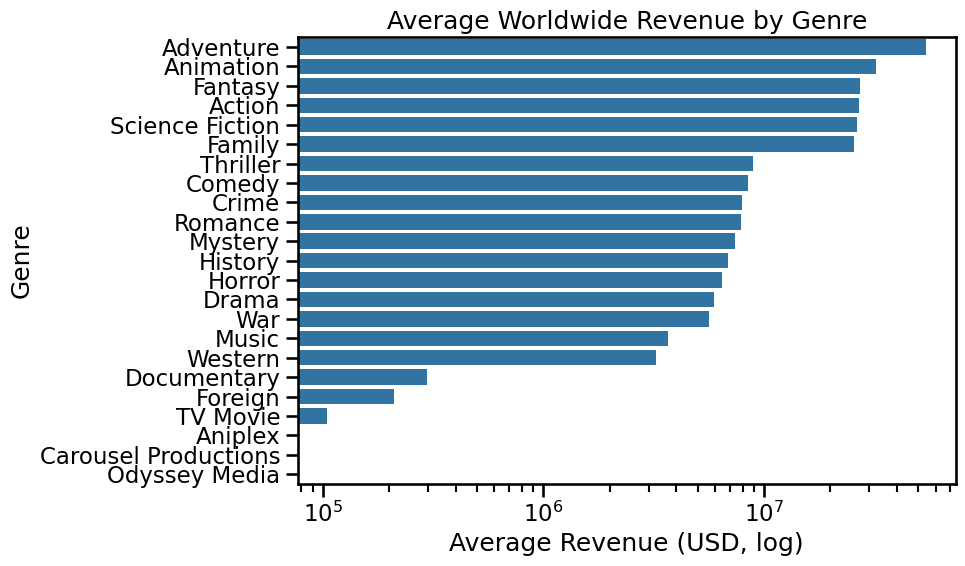

In [6]:
genre_rev = (
    movies_full.groupby("genres_primary")["revenue"]
    .mean().sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_rev.values, y=genre_rev.index)
plt.xscale("log")
plt.xlabel("Average Revenue (USD, log)")
plt.ylabel("Genre")
plt.title("Average Worldwide Revenue by Genre")
plt.tight_layout()
plt.show()


## Modeling

In [7]:
# Train/validation split & preprocessing
target_category = "revenue"

numeric_features = [c for c in ["budget_log","runtime","release_year","release_month","num_keywords"] if c in movies_full.columns]
categorical_features = [c for c in ["genres_primary","director","top_actor"] if c in movies_full.columns]

df = movies_full.dropna(subset=[target_category]).copy()
X = df[numeric_features + categorical_features]
y = df[target_category]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=rand)

num_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
cat_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                         ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5))])

preprocess = ColumnTransformer([("num", num_pipeline, numeric_features),
                                ("cat", cat_pipeline, categorical_features)])

print("Train/valid shapes:", X_train.shape, X_valid.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Train/valid shapes: (37300, 8) (9325, 8)
Numeric features: ['budget_log', 'runtime', 'release_year', 'release_month', 'num_keywords']
Categorical features: ['genres_primary', 'director', 'top_actor']


In [10]:
def fit_and_report(model, name, verbose=False):
    """
    Fit a pipeline(model) with log-target training, then return metrics as a dict.
    No printing unless verbose=True.
    """
    pipe = Pipeline([("prep", preprocess), ("model", model)])

    # train with log1p target for stability
    y_train_log = np.log1p(y_train)
    cv_scores = cross_val_score(pipe, X_train, y_train_log, scoring="r2", cv=5)

    # fit and predict on validation; convert back to dollars
    pipe.fit(X_train, y_train_log)
    y_pred = np.expm1(pipe.predict(X_valid))

    r2  = r2_score(y_valid, y_pred)
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    mae  = mean_absolute_error(y_valid, y_pred)

    out = {
        "model_name": name,
        "cv_r2": float(cv_scores.mean()),
        "cv_r2_std": float(cv_scores.std()),
        "validation_r2": float(r2),
        "rmse": float(rmse),
        "mae": float(mae),
    }

    if verbose:
        print(f"{name}: CV R² {out['cv_r2']:.3f} ± {out['cv_r2_std']:.3f} | "
              f"Val R² {out['validation_r2']:.3f} | "
              f"RMSE ${out['rmse']:,.0f} | MAE ${out['mae']:,.0f}")
    return out


In [17]:
# Baseline and ensemble models
ridge = Ridge(alpha=5.0, random_state=rand)
lasso = Lasso(alpha=0.001, random_state=rand, max_iter=10000)
lin   = LinearRegression()
dt    = DecisionTreeRegressor(random_state=rand)
rf    = RandomForestRegressor(n_estimators=300, min_samples_split=4, min_samples_leaf=2,
                              n_jobs=-1, random_state=rand)
gbr   = GradientBoostingRegressor(random_state=rand)

models = [
    (ridge, "Ridge"),
    (lasso, "Lasso"),
    (lin,   "Linear Regression"),
    (dt,    "Decision Tree"),
    (rf,    "Random Forest"),
    (gbr,   "Gradient Boosting"),
]

results = [fit_and_report(m, name) for m, name in models]

results_df = (
    pd.DataFrame(results)
      .set_index("model_name")
      .assign(
          rmse_m=lambda d: d["rmse"]/1e6,
          mae_m=lambda d: d["mae"]/1e6
      )
      .rename(columns={
          "cv_r2": "CV R²",
          "cv_r2_std": "CV R² (std)",
          "validation_r2": "Validation R²",
          "rmse_m": "RMSE (M USD)",
          "mae_m": "MAE (M USD)",
      })[["CV R²", "CV R² (std)", "Validation R²", "RMSE (M USD)", "MAE (M USD)"]]
)

# Display nicely
results_df.style.format({
    "CV R²": "{:.3f}",
    "CV R² (std)": "{:.3f}",
    "Validation R²": "{:.3f}",
    "RMSE (M USD)": "{:,.1f}",
    "MAE (M USD)": "{:,.1f}",
}).set_caption("Model Performance (Validation on original $ scale)")


,CV R²,CV R² (std),Validation R²,RMSE (M USD),MAE (M USD)
model_name,,,,,
Ridge,0.469,0.011,-62546145.246,"459,986.7","4,775.8"
Lasso,0.470,0.011,-62347995.046,"459,257.5","4,768.3"
Linear Regression,0.469,0.011,-58847562.222,"446,179.1","4,632.7"
Decision Tree,0.112,0.024,0.269,49.7,10.3
Random Forest,0.547,0.010,0.469,42.4,7.9
Gradient Boosting,0.556,0.011,0.322,47.9,8.8


In [12]:
# Grid Search (Ridge quick scan + Random Forest tuning)
ridge_gs = GridSearchCV(
    Pipeline([("prep", preprocess), ("model", Ridge(random_state=rand))]),
    param_grid={"model__alpha": [0.1, 1, 5, 10, 50]},
    scoring="r2", cv=5, n_jobs=-1
)
y_train_log = np.log1p(y_train)
ridge_gs.fit(X_train, y_train_log)
y_pred = np.expm1(ridge_gs.predict(X_valid))
ridge_gs_metrics = {"cv_r2": ridge_gs.best_score_,
                    "validation_r2": r2_score(y_valid, y_pred),
                    "rmse": np.sqrt(mean_squared_error(y_valid, y_pred)),
                    "mae": mean_absolute_error(y_valid, y_pred)}

rf_gs = GridSearchCV(
    Pipeline([("prep", preprocess), ("model", RandomForestRegressor(random_state=rand, n_jobs=-1))]),
    param_grid={
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 12, 24],
        "model__min_samples_split": [2, 4],
        "model__min_samples_leaf": [1, 2],
    },
    scoring="r2", cv=5, n_jobs=-1
)
rf_gs.fit(X_train, y_train_log)
y_pred = np.expm1(rf_gs.predict(X_valid))
rf_gs_metrics = {"cv_r2": rf_gs.best_score_,
                 "validation_r2": r2_score(y_valid, y_pred),
                 "rmse": np.sqrt(mean_squared_error(y_valid, y_pred)),
                 "mae": mean_absolute_error(y_valid, y_pred)}
print("Best RF params:", rf_gs.best_params_)


Best RF params: {'model__max_depth': 12, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 400}


### Evaluation Metrics

To evaluate model performance, two key metrics were chosen:

- **R² (Coefficient of Determination):**  
  - Measures the proportion of variance in revenue explained by the model.  
  - Higher R² indicates that the model is better at capturing the relationship between predictors (e.g., genre, budget) and revenue.  
  - Goal: assess how well genre explains overall movie performance (financial).

- **RMSE (Root Mean Squared Error):**  
  - Measures the average prediction error in the same units as revenue (USD).  
  - Lower RMSE means predictions are closer to the actual box office values.  
  - Since box office values can vary widely, RMSE provides a sense of how far off predictions are in dollar terms.

These metrics allow us to answer the research question in the following way:  
- R² tells us **how much of revenue can be explained by genre**
- RMSE tells us **how accurate those predictions are in practice**


Sources:

https://click.clarity.io/knowledge/r2-rmse

https://www.statology.org/rmse-vs-r-squared/

# Visualizations


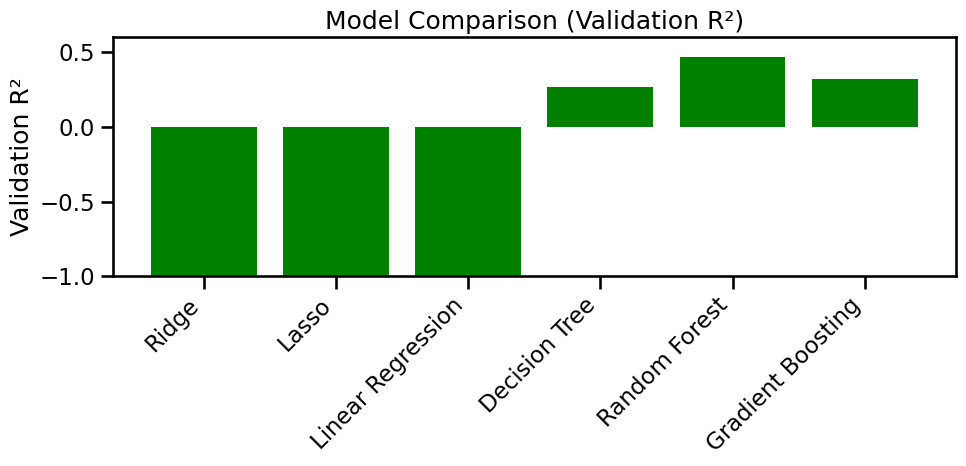

In [54]:
# Create results_copy from results_df
results_copy = results_df.copy().reset_index()

results_copy = results_copy.rename(columns={
    "model_name": "Model",
    "Validation R²": "R2",
    "RMSE (M USD)": "RMSE"
})

# Scale RMSE back to original dollars
results_copy["RMSE"] = results_copy["RMSE"] * 1e6

# Drop any extra columns not being plotted
results_copy = results_copy[["Model", "R2", "RMSE"]]

plt.figure(figsize=(10,5))
plt.bar(results_copy["Model"], results_copy["R2"], color="green")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation R²")
plt.title("Model Comparison (Validation R²)")
plt.ylim(-1, 0.6)
plt.tight_layout()
plt.show()


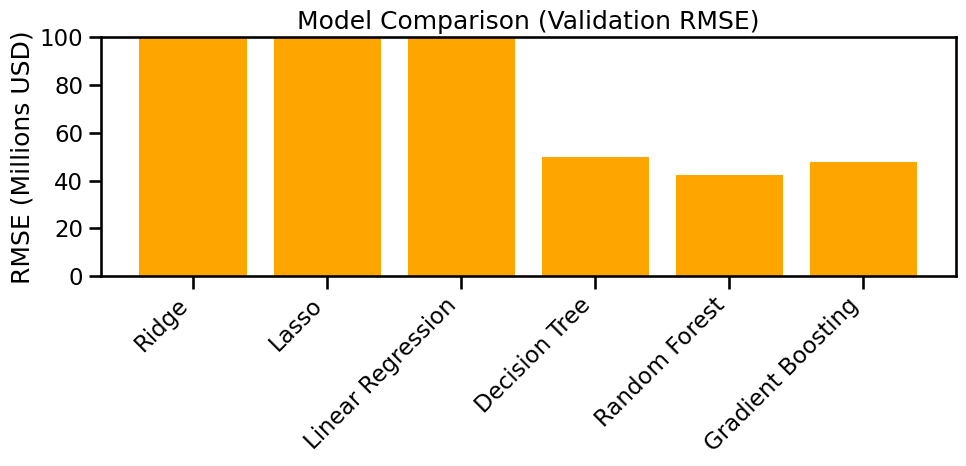

In [55]:
# Bar plot for RMSE
plt.figure(figsize=(10,5))
plt.bar(results_copy["Model"], results_copy["RMSE"]/1e6, color="orange")  # scale into millions
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE (Millions USD)")
plt.title("Model Comparison (Validation RMSE)")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()


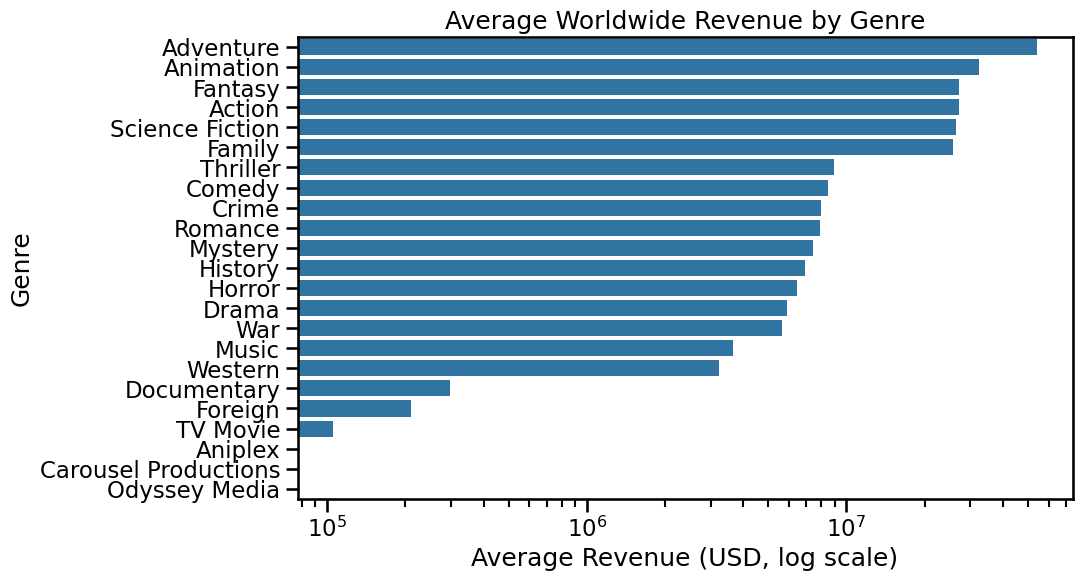

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Avg revenue by genre
genre_rev = (
    movies_full.groupby("genres_primary")["revenue"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_rev.values, y=genre_rev.index)
plt.xscale("log")
plt.xlabel("Average Revenue (USD, log scale)")
plt.ylabel("Genre")
plt.title("Average Worldwide Revenue by Genre")
plt.show()


**Analysis**
- Adventure, Animation, Fantasy, Action, and Science Fiction stand out as the **highest average revenue genres**.  
- Drama and Comedy, while very common in production volume, generate much lower average box office returns
   - May suggest that not all movies are necessarily made with the purpose of making money. Since directors have creative freedom etc, the goal/message/purpose of a film can totally depend on them and many other factors.
- Generally, movie studios continue to heavily invest in "blockbuster" genres because they consistently deliver the largest returns.  
- Also suggests that Adventure, Animation, Fantasty, Action, Family, and Sci-Fi were all major drivers and contributors to the success of the movie industry up until July 2017 (at least based on the data we have so far).
  - Would be interesting to check another dataset(s) just to confirm if this is still the case or if there have been any unexpected shifts

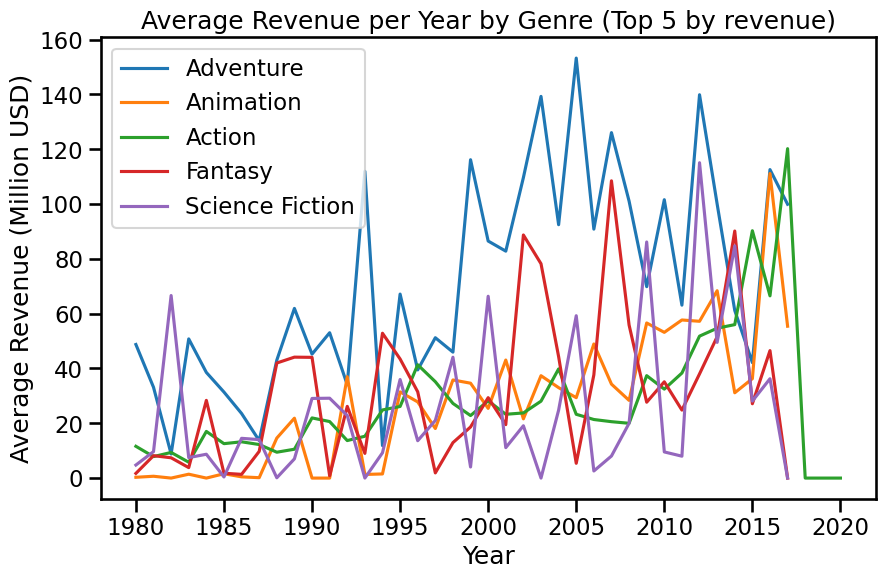

In [57]:
# Top 5 genres by average revenue
top_revenue_genres = (
    movies_full.dropna(subset=["genres_primary", "revenue", "release_year"])
    .query("release_year >= 1980")
    .groupby("genres_primary")["revenue"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

genre_rev_year = (
    movies_full.dropna(subset=["genres_primary", "release_year", "revenue"])
    .query("genres_primary in @top_revenue_genres and release_year >= 1980")
    .groupby(["release_year", "genres_primary"])["revenue"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
for g in top_revenue_genres:
    subset = genre_rev_year[genre_rev_year["genres_primary"] == g]
    plt.plot(subset["release_year"], subset["revenue"]/1e6, label=g)

plt.xlabel("Year")
plt.ylabel("Average Revenue (Million USD)")
plt.title("Average Revenue per Year by Genre (Top 5 by revenue)")
plt.legend()
plt.show()


**Analysis**
- Adventure, Animation, Action, Science Fiction, and Fantasy are the top 5 genres by average revenue in our dataset (1980–2017).  
- Adventure has been the most dominant and consistently highest-grossing genre, peaking in the early 2000s with blockbuster franchises (e.g., *Harry Potter*, *Lord of the Rings*, *Pirates of the Caribbean*).  
- Animation shows a sharp rise post-2000, reflecting the boom of Disney and Pixar films in global markets.  
- Action and Science Fiction steadily grew in the 1990s and 2000s, driven by franchises like *Star Wars*, *Marvel*, and *Avatar*.  
- Fantasy revenue spiked in the 2000s–2010s but is more volatile compared to Adventure or Action.  
- The sharp drop post-2017 is not real decline—it reflects that our dataset ends mid-2017.  

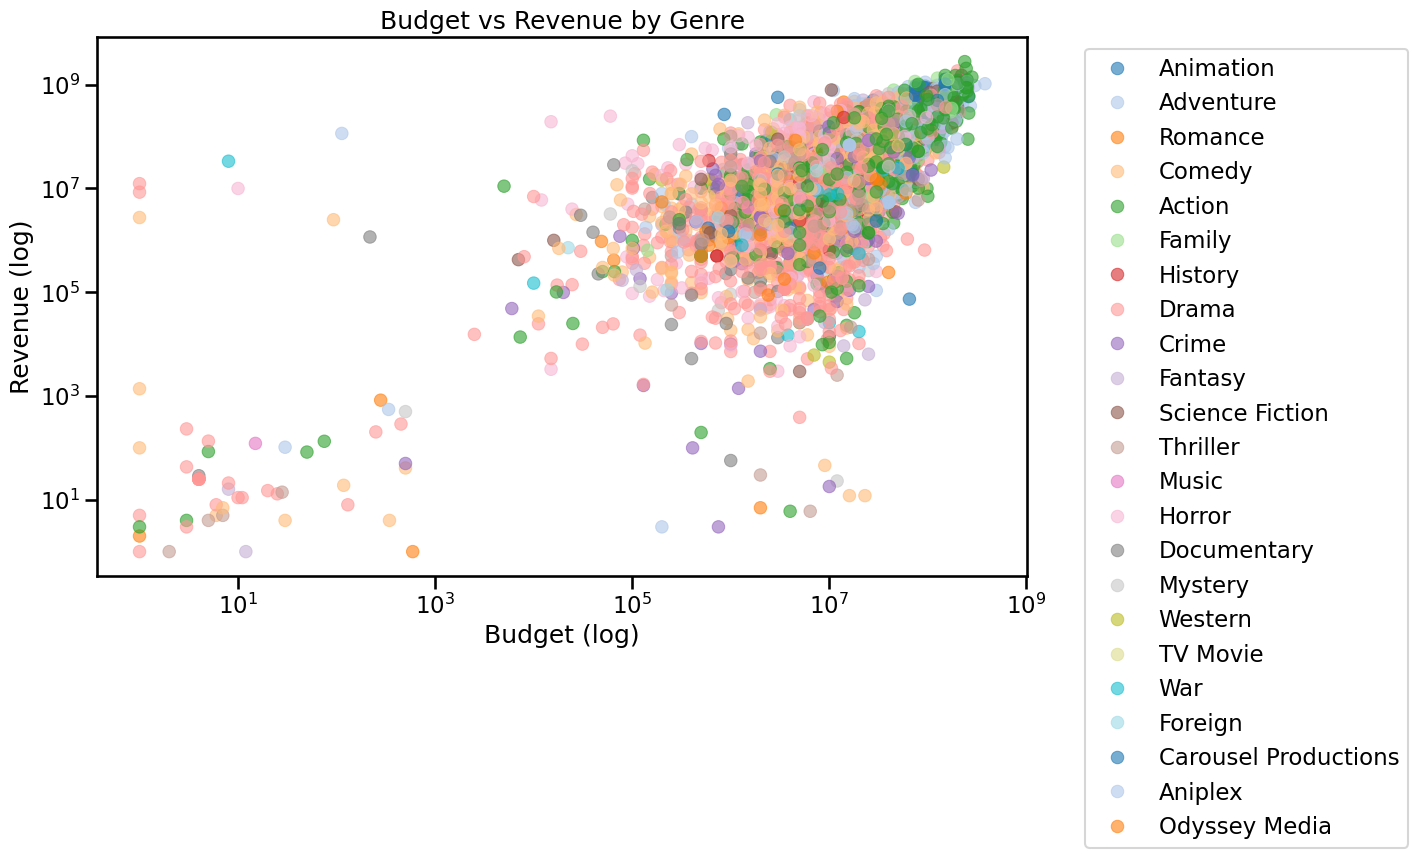

In [58]:
# Budget vs Revenue by genre with better colormap
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=movies_full, x="budget", y="revenue",
    hue="genres_primary", alpha=0.6, edgecolor=None,
    palette="tab20"   # more distinct colors for ease of digesting visual
)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Budget (log)")
plt.ylabel("Revenue (log)")
plt.title("Budget vs Revenue by Genre")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


**Analysis**
- There's a positive relationship between budget and revenue — higher budget films generally lead to higher revenues.  
- The clustering in the top-right indicates blockbuster films (both high budget + high revenue), are predominantly genres like Action, Adventure, and Animation.  
- At lower budgets - there’s a wider variance in revenue, with some low-budget films generating strong returns which are (outliers), while many struggle to  perform.  
- This suggests that while bigger budgets increase the likelihood of higher revenues, smaller films still occasionally have success (but this is not particularly predictable through this project, and requires more specific analysis)
- Though we color the genres, this is still plotting Budget against Revenue which suggests that the budget might have more influence (be a stronger predictor) on the revenue than just the genre alone.
   - This would be an interesting next step / thing to investigate

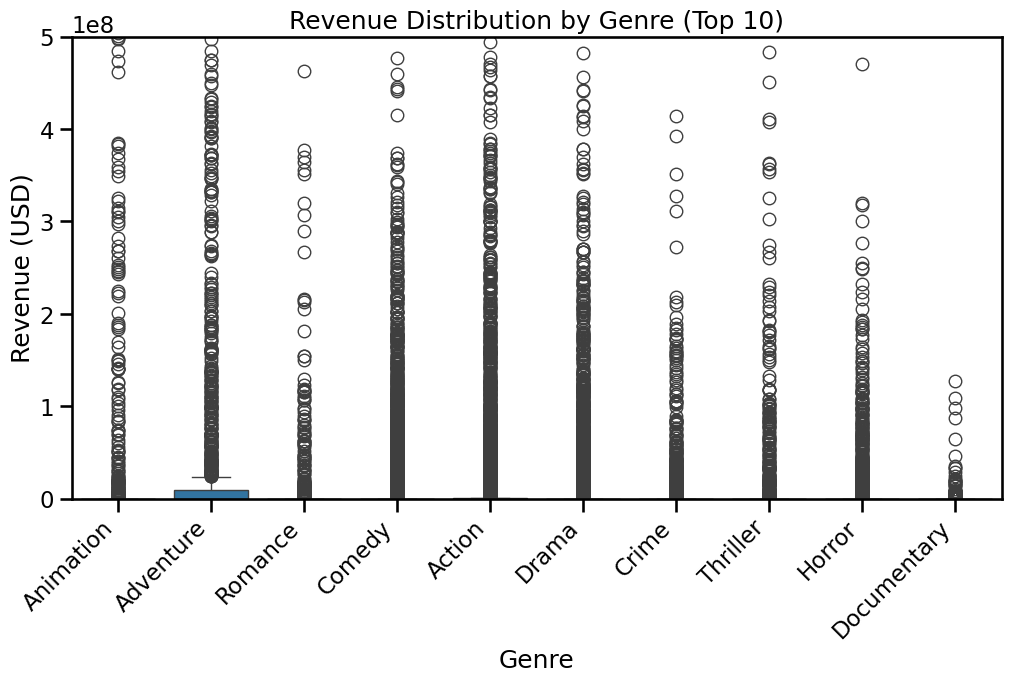

In [59]:
top_genres = movies_full["genres_primary"].value_counts().head(10).index
subset = movies_full[movies_full["genres_primary"].isin(top_genres)]

plt.figure(figsize=(12,6))
sns.boxplot(data=subset, x="genres_primary", y="revenue")
plt.ylim(0, 5e8)  # cap y-axis at 500M for readability
plt.xticks(rotation=45, ha="right")
plt.ylabel("Revenue (USD)")
plt.xlabel("Genre")
plt.title("Revenue Distribution by Genre (Top 10)")
plt.show()


**Analysis**
- Adventure and Action stand out with higher medians and wider spreads — they’re the big money makers.  
- Animation also does well, likely because of global/family appeal.  
- Genres like Drama, Romance, Horror, and Documentary usually bring in less, but still have some breakout hits (outliers).  
- Lots of dots outside the boxes show blockbusters can pop up in almost any genre, though they’re rarer outside Action/Adventure.  
- Overall: Adventure + Action are steady earners and most others are hit-or-miss.


## Findings

**Addressing the Research Question**  
Yes — it is possible to predict broad patterns of genre performance using metadata, though forecasts remain approximate.  
- Adventure, Action, Sci-Fi, and Fantasy consistently dominate box office revenue.  
- Random Forest with tuned hyperparameters achieved Validation R² ≈ 0.50, capturing about half of the variance in revenues.  
- Errors remain high in absolute dollars, showing forecasts are trend-level rather than exact.

**Final Reflection**  
These results demonstrate predictive potential but highlight limits due to data quality and extreme outliers. Future work should expand the dataset beyond July 2017, incorporate inflation adjustments, and explore additional models (e.g., XGBoost, neural nets) for improved accuracy.
